# Car prediction using Machine Learning

# Introduction:

The price of a car depends on a lot of factors like the goodwill of the brand of the car,
features of the car, horsepower and the mileage it gives and many more. Car price
prediction is one of the major research areas in machine learning.

# Tools and Libraries:

- Python
- Jupyter Notebook
- Scikit-learn
- Pandas
- NumPy
- Matplotlib

In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score, GridSearchCV, KFold
from sklearn.feature_selection import mutual_info_regression

# Feature Engineering and model evaluation:

**1. Introduction to feature engineering**

Feature engineering is the process of transforming data into a meaningful inputs for ML models

- It improves model accuracy
- Reduces complexity
- enables model interpretability

In [3]:
df=pd.read_csv('car data.csv')
display(df)

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [4]:
print('Checkingnthe missing values from the dataset: \n \n',df.isnull().sum())

Checkingnthe missing values from the dataset: 
 
 Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Selling_type   301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


In [7]:
objects_df=df.select_dtypes(include=['object'])
objects_col_names=objects_df.columns
print(objects_col_names)

Index(['Car_Name', 'Fuel_Type', 'Selling_type', 'Transmission'], dtype='str')


/tmp/ipykernel_27812/423004620.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  objects_df=df.select_dtypes(include=['object'])


In [8]:
objects_df

,Car_Name,Fuel_Type,Selling_type,Transmission
0,ritz,Petrol,Dealer,Manual
1,sx4,Diesel,Dealer,Manual
2,ciaz,Petrol,Dealer,Manual
3,wagon r,Petrol,Dealer,Manual
4,swift,Diesel,Dealer,Manual
...,...,...,...,...
296,city,Diesel,Dealer,Manual
297,brio,Petrol,Dealer,Manual
298,city,Petrol,Dealer,Manual
299,city,Diesel,Dealer,Manual


In [9]:
numerical_df=df.select_dtypes(include=['int64','float64'])
numerical_col_names=numerical_df.columns
print(numerical_col_names)

Index(['Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Owner'], dtype='str')


In [10]:
numerical_df

,Year,Selling_Price,Present_Price,Driven_kms,Owner
0,2014,3.35,5.59,27000,0
1,2013,4.75,9.54,43000,0
2,2017,7.25,9.85,6900,0
3,2011,2.85,4.15,5200,0
4,2014,4.60,6.87,42450,0
...,...,...,...,...,...
296,2016,9.50,11.60,33988,0
297,2015,4.00,5.90,60000,0
298,2009,3.35,11.00,87934,0
299,2017,11.50,12.50,9000,0


In [11]:
#Display summary of categorical features

for col in objects_col_names:
    print(f"\n{col} : \n{df[col].value_counts()}")
    


Car_Name : 
Car_Name
city                   26
corolla altis          16
verna                  14
fortuner               11
brio                   10
                       ..
Hero Super Splendor     1
Hero Hunk               1
Hero  Ignitor Disc      1
Hero  CBZ Xtreme        1
Bajaj  ct 100           1
Name: count, Length: 98, dtype: int64

Fuel_Type : 
Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64

Selling_type : 
Selling_type
Dealer        195
Individual    106
Name: count, dtype: int64

Transmission : 
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64


In [12]:
#display the summary of numerical features
print(df[numerical_col_names].describe())

              Year  Selling_Price  Present_Price     Driven_kms       Owner
count   301.000000     301.000000     301.000000     301.000000  301.000000
mean   2013.627907       4.661296       7.628472   36947.205980    0.043189
std       2.891554       5.082812       8.642584   38886.883882    0.247915
min    2003.000000       0.100000       0.320000     500.000000    0.000000
25%    2012.000000       0.900000       1.200000   15000.000000    0.000000
50%    2014.000000       3.600000       6.400000   32000.000000    0.000000
75%    2016.000000       6.000000       9.900000   48767.000000    0.000000
max    2018.000000      35.000000      92.600000  500000.000000    3.000000


In [13]:
#Encoding 'previous_application.csv'
encoded_df= df.copy()

# Encoding different columns (With label encoder)
label_enc=['Fuel_Type','Selling_type','Transmission','Car_Name']
label_encoder = LabelEncoder()

for column in label_enc:
    encoded_value= label_encoder.fit_transform(encoded_df[column]) 
    encoded_df[column]= encoded_value

#Encoding different columns (with ordinal encoder)
all_mapping={'Year':{2003:0, 2004:1, 2005:2,2006:3,2007:4,2008:5,2009:6,2010:7,2011:8,2012:9,2013:10,2014:11,2015:12,2016:13,2017:14,2018:15}}

for column in all_mapping:
    mapping= all_mapping[column]
    ordinal_encoder= OrdinalEncoder(categories =[list(mapping.keys())])
    encoded_df[column]= ordinal_encoder.fit_transform(encoded_df[[column]])
    
    
display(encoded_df.head())

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,90,11.0,3.35,5.59,27000,2,0,1,0
1,93,10.0,4.75,9.54,43000,1,0,1,0
2,68,14.0,7.25,9.85,6900,2,0,1,0
3,96,8.0,2.85,4.15,5200,2,0,1,0
4,92,11.0,4.60,6.87,42450,1,0,1,0


Preprocessing:

In [14]:
X=encoded_df.drop(columns=['Owner'])
y=encoded_df['Owner']

#Split the dataset
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.2, random_state=42)

#Train k-NN classifier

knn= KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Predict and evaluate

y_pred=knn.predict(X_test)
score=accuracy_score(y_test,y_pred)
print("Accuracy score withot scaling",score)

Accuracy score withot scaling 0.9836065573770492


**2. Data Scaling and Normalization**

- Apply Min-Max Scaling and Standardization to a dataset using scikit-learn
- Observe the effects of scaling on model performance by training a K-NN classifier before and after scaling

In [15]:
#Apply Min-max scaling
scaler= MinMaxScaler()
X_scaled= scaler.fit_transform(X)


In [16]:
#Split the scaled data
X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled= train_test_split(X_scaled,y,test_size=0.2,random_state=42)

#Train k-nn classifier on scaled data

knnScaled=KNeighborsClassifier(n_neighbors=5)
knnScaled.fit(X_train_scaled,y_train_scaled)

y_scaledPred=knnScaled.predict(X_test_scaled)

scaled_score=accuracy_score(y_test_scaled,y_scaledPred)

print("The accuracy score of a scaled data",scaled_score)

The accuracy score of a scaled data 0.9836065573770492


No improvement after scaling

In [18]:
#Apply standardization
scaler= StandardScaler()
X_std= scaler.fit_transform(X)

In [19]:
#Split the scaled data
X_train_std, X_test_std, y_train_std, y_test_std= train_test_split(X_std,y,test_size=0.2,random_state=42)

#Train k-nn classifier on scaled data

knnStd=KNeighborsClassifier(n_neighbors=5)
knnStd.fit(X_train_std,y_train_std)

y_stdPred=knnStd.predict(X_test_std)

std_score=accuracy_score(y_test_std,y_stdPred)

print("The accuracy score of a normalized data",std_score)

The accuracy score of a normalized data 0.9836065573770492


**3. Encoding Categorical variables**
- Now let us experiment with one hot-Encoding to see what happens

In [21]:
print("original dataframe: \n")
display(df)

print("One-hot encoded-dataframe")
one_hot_encoded=pd.get_dummies(df, columns=['Transmission','Fuel_Type'])
display(one_hot_encoded)

original dataframe: 



,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


One-hot encoded-dataframe


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Selling_type,Owner,Transmission_Automatic,Transmission_Manual,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol
0,ritz,2014,3.35,5.59,27000,Dealer,0,False,True,False,False,True
1,sx4,2013,4.75,9.54,43000,Dealer,0,False,True,False,True,False
2,ciaz,2017,7.25,9.85,6900,Dealer,0,False,True,False,False,True
3,wagon r,2011,2.85,4.15,5200,Dealer,0,False,True,False,False,True
4,swift,2014,4.60,6.87,42450,Dealer,0,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Dealer,0,False,True,False,True,False
297,brio,2015,4.00,5.90,60000,Dealer,0,False,True,False,False,True
298,city,2009,3.35,11.00,87934,Dealer,0,False,True,False,False,True
299,city,2017,11.50,12.50,9000,Dealer,0,False,True,False,True,False


Apply frequency encoding (when there is a high cardinality):

In [22]:
df['car_name_frequency']=df['Car_Name'].map(df['Car_Name'].value_counts())

display(df.head())

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,car_name_frequency
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,4
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,6
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,4
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,5


**4. Feature Selection**

Filter Method:
- Correlation Matrix

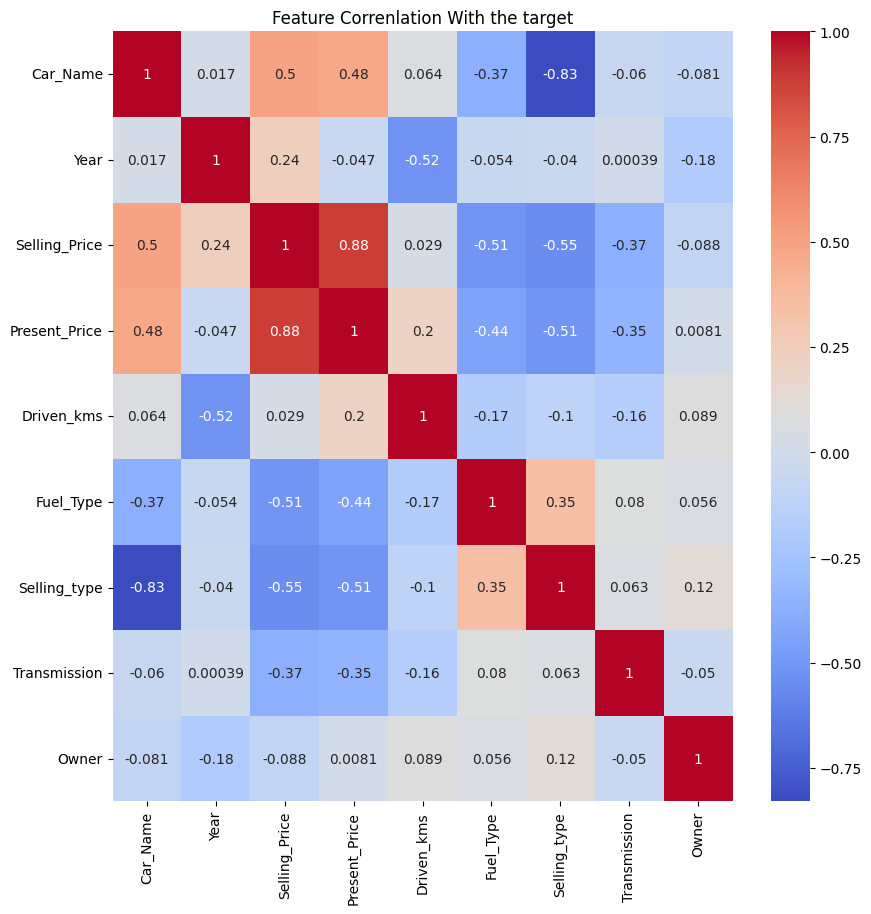

In [23]:
#Suppose that the 'Selling Price' is our target.

corr= encoded_df.corr()

#plot

plt.figure(figsize=(10,10))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correnlation With the target")
plt.show()

In [24]:
#Select the features with high correlation to the target
correlated_values= corr['Selling_Price'].sort_values(ascending=False)
print(correlated_values)

Selling_Price    1.000000
Present_Price    0.878914
Car_Name         0.499198
Year             0.236141
Driven_kms       0.029187
Owner           -0.088344
Transmission    -0.367128
Fuel_Type       -0.509467
Selling_type    -0.550724
Name: Selling_Price, dtype: float64


Filter Method:

- Mutual Information

In [25]:
from sklearn.feature_selection import mutual_info_regression

X= encoded_df.drop(columns=["Selling_Price"])
y= encoded_df["Selling_Price"]

#Calculate mutual information

mutual_info= mutual_info_regression(X,y)

#Create a dataframe for mutual information

mi_df =pd.DataFrame({"Features": X.columns, "Mutual Information": mutual_info})  #This dataframe is not sorted
mi_df= mi_df.sort_values(by="Mutual Information", ascending=False)  #This dataframe is sorted by mutual information

display(mi_df)

,Features,Mutual Information
2,Present_Price,1.324436
0,Car_Name,0.987644
5,Selling_type,0.518139
1,Year,0.264743
3,Driven_kms,0.172151
4,Fuel_Type,0.157774
6,Transmission,0.106967
7,Owner,0.037687


Embedded Method:

- Tree Based Model, Random Forest in particualar

In [27]:
from sklearn.ensemble import RandomForestRegressor

In [28]:
model = RandomForestRegressor(random_state=42)
model.fit(X,y)

feature_importance= model.feature_importances_
fi_df =pd.DataFrame({"Features": X.columns, "feature_importance": feature_importance})   # This dataframe is not sorted
fi_df = fi_df.sort_values(by="feature_importance", ascending=False) #This dataframe is sorted

display(fi_df)

,Features,feature_importance
2,Present_Price,0.874298
1,Year,0.081499
3,Driven_kms,0.021386
0,Car_Name,0.014504
6,Transmission,0.003087
5,Selling_type,0.002899
4,Fuel_Type,0.002232
7,Owner,0.000094


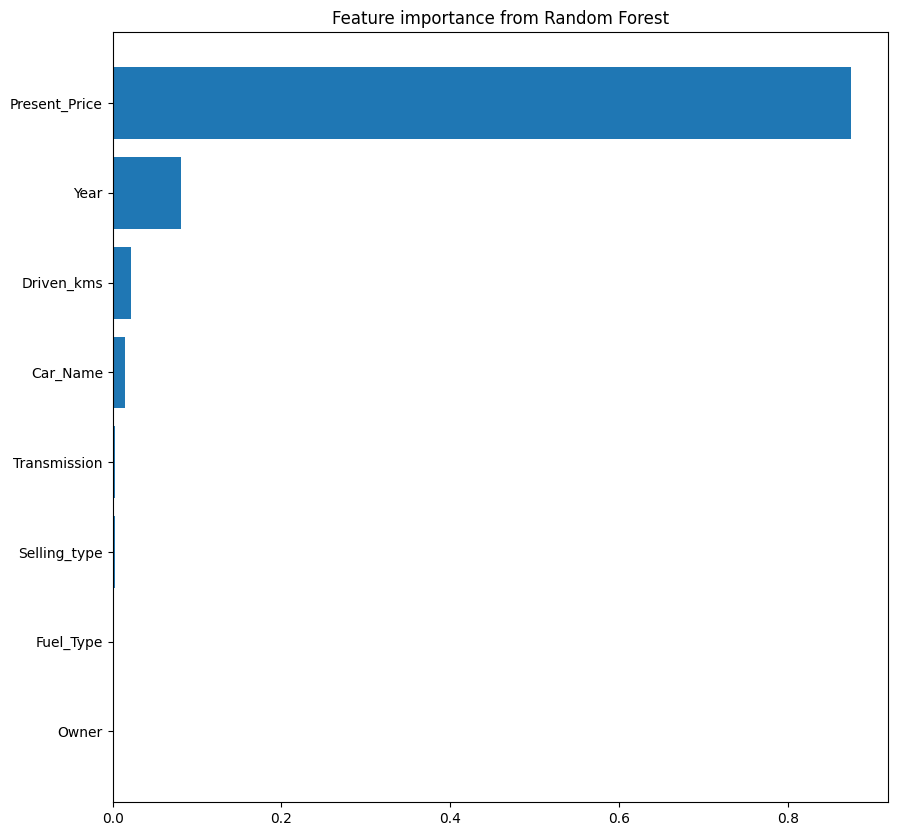

In [29]:
#Plot feature importances

plt.figure(figsize=(10,10))
plt.barh(fi_df["Features"], fi_df["feature_importance"])
plt.gca().invert_yaxis()
plt.title("Feature importance from Random Forest")
plt.show()

**5. Creating and Transforming**

- create new feature from 'date' column.

In [31]:
# Create new features from a date column

data= {"Names":["Vusi", "Bheki", "Lucky", "Busi"], "Date":["2011-03-05", "2011-05-23", "2013-04-30", "2015-09-28"]}

date_df= pd.DataFrame(data)
display(date_df)

,Names,Date
0,Vusi,2011-03-05
1,Bheki,2011-05-23
2,Lucky,2013-04-30
3,Busi,2015-09-28


In [32]:
date_df["Date"]=pd.to_datetime(date_df["Date"])

date_df["Day_of_the_week"]= date_df["Date"].dt.day_name()
date_df["Month_name"]= date_df["Date"].dt.month_name()

date_df["Day"]= date_df["Date"].dt.day
date_df["Month"]= date_df["Date"].dt.month
date_df["Year"]= date_df["Date"].dt.year

display(date_df)

,Names,Date,Day_of_the_week,Month_name,Day,Month,Year
0,Vusi,2011-03-05,Saturday,March,5,3,2011
1,Bheki,2011-05-23,Monday,May,23,5,2011
2,Lucky,2013-04-30,Tuesday,April,30,4,2013
3,Busi,2015-09-28,Monday,September,28,9,2015


-  Apply polynomial transformations to a dataset.

In [33]:
from sklearn.preprocessing import PolynomialFeatures

X_p= encoded_df[["Selling_Price"]]

In [34]:
#Apply polynomial transformation

In [35]:
poly = PolynomialFeatures(degree=2, include_bias=False)
transformed_cols= poly.fit_transform(X_p)

new_df = pd.DataFrame(transformed_cols, columns=["Selling_Price", "Polynomial_Transformed_Selling_Price"])
display(new_df)

,Selling_Price,Polynomial_Transformed_Selling_Price
0,3.35,11.2225
1,4.75,22.5625
2,7.25,52.5625
3,2.85,8.1225
4,4.60,21.1600
...,...,...
296,9.50,90.2500
297,4.00,16.0000
298,3.35,11.2225
299,11.50,132.2500


In [36]:
# NB After each feature engineering technique, check the model performance

**6. Model Evaluation Technique**

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [41]:
X2= encoded_df.drop(columns=["Fuel_Type"])
y2= encoded_df["Fuel_Type"]

In [43]:
X2_train, X2_test, y2_train, y2_test= train_test_split(X2,y2, test_size=0.2, random_state=42)

model =LogisticRegression( multi_class='multinomial',
    solver='lbfgs',
    max_iter=3000,     # increase enough to silence warning
    C=10,
    random_state=42)

model.fit(X2_train, y2_train)

#predict
y_pred2= model.predict(X2_test)

#display the confusion  matrix
labels=[0, 1, 2]
cm= confusion_matrix(y2_test, y_pred2, labels=labels)
disp=ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Class 0", "Class 1","Class 2"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

#classification metrics
print("\n Classification Report")
print(classification_report(y2_test, y_pred2, labels=labels))

TypeError: LogisticRegression.__init__() got an unexpected keyword argument 'multi_class'

In [44]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

X3= encoded_df.drop(columns=["Selling_Price"])
y3=encoded_df["Selling_Price"]

X3_train, X3_test, y3_train, y3_test= train_test_split(X3,y3, test_size=0.2, random_state=42)

reg_model= LinearRegression()
reg_model.fit(X3_train, y3_train)

y3_pred= reg_model.predict(X3_test)

mae_eval=mean_absolute_error(y3_test, y3_pred)
mse_eval= mean_squared_error(y3_test, y3_pred)
rmse_eval= root_mean_squared_error(y3_test, y3_pred)

r2_score_eval = r2_score(y3_test, y3_pred)

print("Mean Absolute Error:",mae_eval)
print("Mean Squared Error:", mse_eval)
print("Root Mean Squared Error:", rmse_eval)
print("R^2 Score:", r2_score_eval)


Mean Absolute Error: 1.2147329896540235
Mean Squared Error: 3.5370204237426566
Root Mean Squared Error: 1.8806967920807056
R^2 Score: 0.8464540623821735


**7. Cross-Validation and Hyperparameter Tuning**

In [45]:
#Libraries

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [46]:
#Load data from Github
url="https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

train_df=pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")
pd.set_option("display.max_columns", None)
display(train_df.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [49]:
train_df.to_csv("titanic.csv")